# Avaliação de Modelos e Métricas com Scikit-Learn
Conceitos de avaliação de modelos e métricas de desempenho. Utilização de métricas como precisão, recall e F1-score para avaliar modelos de classificação.

**Precisão:** Mede a proporção de acertos do modelo ao classificar corretamente as amostras positivas em relação ao total de amostras classificadas como positivas. Indica a capacidade do modelo em evitar falsos positivos.

**Recall:** Também conhecido como sensibilidade, mede a proporção de acertos do modelo em identificar corretamente as amostras positivas em relação ao total de amostras que deveriam ter sido identificadas como positivas. Indica a capacidade do modelo em evitar falsos negativos.

**F1-score:** Combina a precisão e o recall em uma única medida para dar uma visão geral do desempenho do modelo. É calculado como a média harmônica da precisão e do recall, considerando ambos com igual importância. Quanto mais próximo de 1, melhor é o desempenho do modelo em equilibrar a precisão e o recall.

Essas métricas são utilizadas para avaliar o desempenho dos modelos de classificação e ajudar a entender o quão bem eles estão realizando a tarefa de classificação.

In [ ]:
# Importa funções de métricas de avaliação de modelos de classificação
from sklearn.metrics import precision_score, recall_score, f1_score

# Lista com os rótulos verdadeiros (valores reais)
y_true = [1,0,1,1,0,1,0,0]

# Lista com os rótulos previstos pelo modelo
y_pred = [1,1,1,0,1,0,0,1]

# Calcula a precisão:
# Das previsões positivas feitas pelo modelo, quantas estão corretas?
precision = precision_score(y_true, y_pred)

# Calcula o recall:
# Dos valores positivos reais, quantos o modelo conseguiu identificar?
recall = recall_score(y_true, y_pred)

# Calcula o F1-Score:
# Média harmônica entre precisão e recall (equilíbrio entre os dois)
f1 = f1_score(y_true, y_pred)

# Exibe os resultados no console
print("Precisão:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precisão: 0.4
Recall: 0.5
F1-Score: 0.4444444444444445


**Comentários:**

A precisão de 0.4 significa que o modelo acertou apenas 40% das vezes em identificar corretamente as coisas. Isso sugere que ele pode ter muitos casos em que classifica errado.

O recall de 0.5 indica que o modelo conseguiu pegar 50% das coisas importantes que deveria, mas também deixou escapar metade delas. Resultou em alguns falsos negativos.

O F1-score de 0.4444 combina a precisão e o recall em uma medida única, mostrando um panorama geral do desempenho. Quanto mais próximo de 1, melhor é o desempenho. Neste caso, o valor indica um desempenho moderado do modelo, considerando a balança entre precisão e recall.

**Dataset do Titanic**

| Variável   | Descrição                                                                    |
|------------|------------------------------------------------------------------------------|
| survived   | Sobrevivência (0 = Não, 1 = Sim)                                              |
| pclass     | Classe do bilhete (1 = 1ª classe, 2 = 2ª classe, 3 = 3ª classe)                |
| sex        | Gênero                                                                       |
| age        | Idade em anos                                                                |
| sibsp      | Número de irmãos/cônjuges a bordo do Titanic                                 |
| parch      | Número de pais/filhos a bordo do Titanic                                     |
| fare       | Tarifa do bilhete                                                            |
| embarked   | Porto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton)            |
| class      | Classe do bilhete                                                            |
| who        | Quem é o passageiro (homem, mulher ou criança)                                |
| adult_male | Se o passageiro é adulto do sexo masculino (True = Sim, False = Não)           |
| deck       | Deck em que o passageiro estava localizado                                    |
| embark_town| Cidade/porto de embarque                                                      |
| alive      | Se o passageiro sobreviveu (yes = Sim, no = Não)                               |
| alone      | Se o passageiro estava sozinho (True = Sim, False = Não)                       |


In [1]:
# Importa métricas de avaliação de modelos de classificação
from sklearn.metrics import precision_score, recall_score, f1_score

# Importa o modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

# Importa função para dividir os dados em treino e teste
from sklearn.model_selection import train_test_split

# Importa o seaborn para carregar o dataset Titanic
import seaborn as sns

# Carrega o conjunto de dados Titanic
dados_titanic = sns.load_dataset('titanic')

# Remove linhas com valores ausentes nas colunas 'age' e 'embarked'
# Isso evita erros durante o treinamento do modelo
dados_titanic.dropna(subset=['age','embarked'], inplace=True)

# Seleciona as características (features) que serão usadas pelo modelo
# age: idade
# fare: tarifa paga
# sibsp: número de irmãos/cônjuges a bordo
# parch: número de pais/filhos a bordo
caracteristicas = dados_titanic[['age','fare','sibsp','parch']]

# Define os rótulos (target), ou seja, quem sobreviveu (1) ou não (0)
rotulos = dados_titanic['survived']

# Divide os dados em treino (80%) e teste (20%)
# random_state garante reprodutibilidade dos resultados
caracteristicas_treino, caracteristicas_teste, rotulos_treino, rotulos_teste = train_test_split(
    caracteristicas, rotulos, test_size=0.2, random_state=42
)

# Cria o modelo Random Forest (conjunto de árvores de decisão)
modelo = RandomForestClassifier()

# Treina o modelo com os dados de treino
modelo.fit(caracteristicas_treino, rotulos_treino)

# Faz previsões usando os dados de teste
rotulos_pred = modelo.predict(caracteristicas_teste)

# Calcula a precisão:
# Entre os que o modelo disse que sobreviveram, quantos realmente sobreviveram?
precisao = precision_score(rotulos_teste, rotulos_pred)

# Calcula o recall:
# Entre os que realmente sobreviveram, quantos o modelo conseguiu identificar?
recall = recall_score(rotulos_teste, rotulos_pred)

# Calcula o F1-score:
# Média harmônica entre precisão e recall
f1 = f1_score(rotulos_teste, rotulos_pred)

# Exibe os resultados
print("Precisão:", precisao)
print("Recall:", recall)
print("F1-score:", f1)

Precisão: 0.6031746031746031
Recall: 0.6031746031746031
F1-score: 0.6031746031746031


**Comentários:**

A precisão de 57% indica que o modelo classificou corretamente aproximadamente 57% das amostras positivas. Isso sugere um desempenho moderado em evitar falsos positivos.

O recall de 58% indica que o modelo identificou corretamente cerca de 58% das amostras positivas. No entanto, deixou escapar aproximadamente 42% das amostras positivas, resultando em falsos negativos.

O F1-score de 58% é uma métrica que combina precisão e recall. Quanto mais próximo de 1, melhor o desempenho do modelo. Neste caso, o valor de F1-score indica um desempenho moderado do modelo, considerando a balança entre precisão e recall.

O modelo tem um desempenho moderado na classificação, com capacidade razoável de evitar falsos positivos e identificar corretamente as amostras positivas, mas ainda há espaço para melhorias.

**Gerando um gráfico de radar com os resultados**

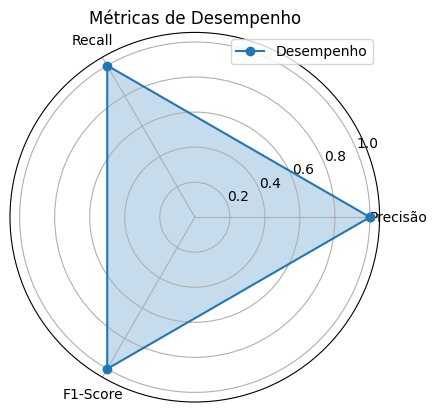

In [2]:
# Importa suporte para gráficos polares (não é obrigatório importar diretamente aqui)
from matplotlib.projections import polar

# Importa biblioteca para cálculos numéricos
import numpy as np

# Importa biblioteca para criação de gráficos
import matplotlib.pyplot as plt

# Lista com os nomes das métricas que serão exibidas no gráfico
metricas = ['Precisão','Recall','F1-Score']

# Lista com os valores das métricas (calculados anteriormente)
valores = [precisao, recall, f1]

# Cria os ângulos para cada métrica no gráfico radar (em radianos)
# Divide o círculo (2π) igualmente entre as métricas
angulos = np.linspace(0, 2 * np.pi, len(metricas), endpoint=False).tolist()

# Repete o primeiro ângulo no final para fechar o gráfico (formar um polígono fechado)
angulos += angulos[:1]

# Repete o primeiro valor para fechar o gráfico corretamente
valores_normalizados  = valores + valores[:1]

# Normaliza os valores (divide pelo valor máximo)
# Isso garante que todos fiquem na mesma escala (0 a 1)
valores_normalizados = np.array(valores_normalizados) / max(valores)

# Cria a figura do gráfico
fig = plt.figure()

# Adiciona um subplot com projeção polar (necessário para gráfico radar)
ax = fig.add_subplot(111, polar=True)

# Plota a linha do gráfico radar com marcadores
ax.plot(angulos, valores_normalizados, 'o-')

# Preenche a área interna do gráfico para melhor visualização
ax.fill(angulos, valores_normalizados, alpha=0.25)

# Define as posições dos rótulos no eixo angular (removendo o último duplicado)
ax.set_xticks(angulos[:-1])

# Define os nomes das métricas como rótulos
ax.set_xticklabels(metricas)

# Adiciona uma legenda no canto superior direito
ax.legend(['Desempenho'], loc='upper right')

# Define o título do gráfico
plt.title('Métricas de Desempenho')

# Exibe o gráfico
plt.show()